# WP2.3 - Multiphase short circuit (radials)

This Notebook shows exemplary tests that are implemented in the sce_test/test_sce.py file in test_wp23

Therefore it must be run in an environment where the pandapower test folders can be found by the jupyter server's python environment.\
This can be done by checking out the git branche sce in pandapower and locally initializing the repository by using `pip install -e .`.

Further information on running short-circuit calculations in pandapower can be found in the [documentation on shortcircuit](https://pandapower.readthedocs.io/en/latest/shortcircuit/run.html) and the [shortcircuit tutorial](https://github.com/e2nIEE/pandapower/blob/sce/tutorials/shortcircuit/shortcircuit.ipynb).


In [25]:
import os
from pandapower import pp_dir
from pandapower.plotting import simple_plot, create_generic_coordinates, set_line_geodata_from_bus_geodata
from pandapower.test.shortcircuit.sce_tests.functions_tests import load_test_case_data, run_test_cases, compare_results
import pandas as pd
testfiles_path = os.path.join(pp_dir, 'test', 'shortcircuit', 'sce_tests')

In order to execute pandapower short circuit calculations with multi-phase grids adaptations in regard to the element tables e.g. lines and transformers in pandapower are necessary. Once the adaptations are done pandapower is capable of calculating short circuits in 1-phase and 2-phase grids.

## 1 phase grid equivalent modelling

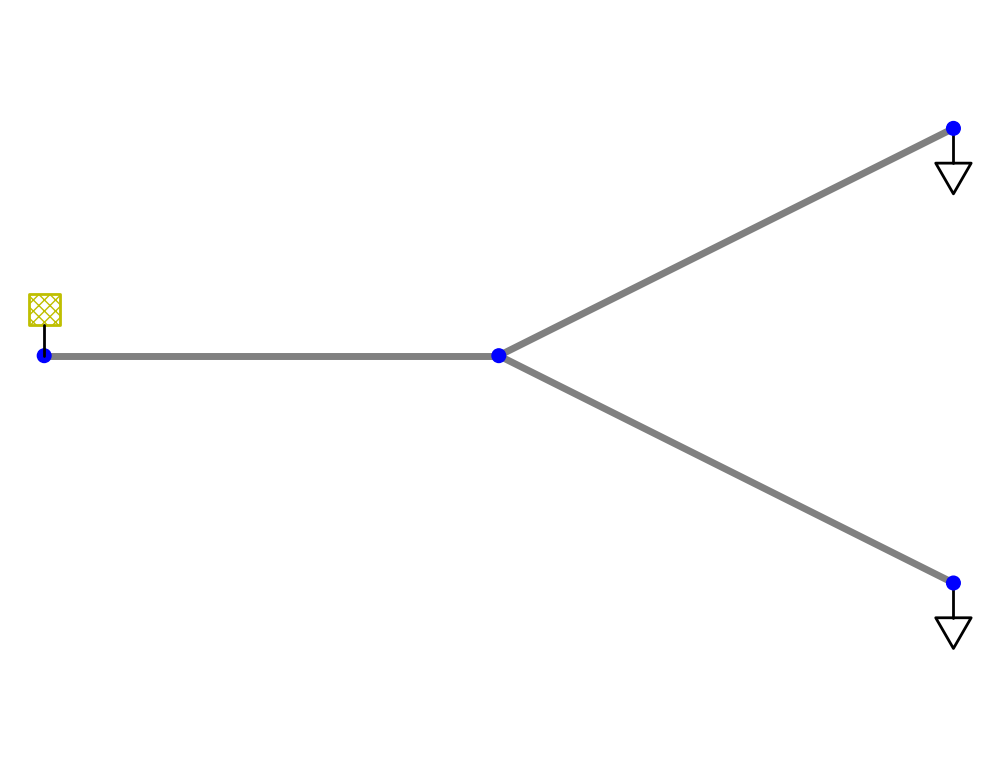

In [26]:
net_name = "1_four_bus_radial_1ph_grid_MP"
fault_location_bus = 3
net, dataframes = load_test_case_data(net_name, fault_location_bus)
relevant_columns = ["name", "r_ohm_per_km", "x_ohm_per_km", "c_nf_per_km", "r0_ohm_per_km", "x0_ohm_per_km", "c0_nf_per_km"]

def plot(net):
    create_generic_coordinates(net, overwrite=True)
    set_line_geodata_from_bus_geodata(net, overwrite=True)

    simple_plot(
        net,
        line_width=5.,
        plot_loads=True, plot_gens=False, plot_sgens=False,
        load_size=3., gen_size=3., sgen_size=3., ext_grid_size=1.5
    )

plot(net)

This simple example illustrates how a 1-phase grid can be modeled as a 3-phase grid. Therefore, adaptations in the pandapower element tables e.g. lines and transformers are neccesarry. Only the zero sequence parameters for this case will be affected. Positive and Negative sequence parameters are the same and remain unchanged.

\begin{align*}
\Huge Z_{\text{1-1ph}} &= \Huge Z_{\text{1-3ph}} \\
\\
\Huge Z_{\text{2-1ph}} &= \Huge Z_{\text{2-3ph}} \\
\\
\Huge Z_{\text{0-1ph}} &= \Huge 0 \\
\end{align*}

In this small example grid we model three lines in total with one 3-phase line and two equivalent 1-phase lines with the same standard type.

In [27]:
net.line.std_type

0      NA2XRY 3x300sm 0.6/1kV_3ph
1    NA2XRY 3x300sm 0.6/1kV_3-1ph
2    NA2XRY 3x300sm 0.6/1kV_3-1ph
Name: std_type, dtype: object

Comparing the relevant parameters resistance, reactance and capacitance we can see the equivalent modeling of the 1-phase lines was correctly applied. The impacting parameters for positive/negative sequence for resistance and reactance and capacitance remain unchanged. Zero sequence parameters are set to zero.

In [28]:
net.line[relevant_columns]

,name,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,r0_ohm_per_km,x0_ohm_per_km,c0_nf_per_km
0,Line_0_3ph,0.1023,0.069115,0,0.409400,0.276460,367.599994
1,Line_1_3-1ph,0.1023,0.069115,0,0.000001,0.000001,0.000001
2,Line_2_3-1ph,0.1023,0.069115,0,0.000001,0.000001,0.000001


## Test Case 1: Four Bus Radial 1 phase grid

In [29]:
fault = "LG"
case = "max"
fault_values = (0.0, 0.0)
lv_tol_percents = 10
fault_location_bus = 3
is_branch_test = True
bus_or_branch = "branch" if is_branch_test else "bus"

columns_to_check, net_df, pf_results = run_test_cases(net, dataframes[bus_or_branch], fault, case, fault_values, lv_tol_percents, fault_location_bus, is_branch_test)
columns_to_check

Index(['ikss_a_from_ka', 'ikss_a_from_degree', 'ikss_a_to_ka',
       'ikss_a_to_degree', 'p_a_from_mw', 'q_a_from_mvar', 'p_a_to_mw',
       'q_a_to_mvar', 'vm_a_from_pu', 'va_a_from_degree', 'vm_a_to_pu',
       'va_a_to_degree', 'ikss_b_from_ka', 'ikss_b_from_degree',
       'ikss_b_to_ka', 'ikss_b_to_degree', 'p_b_from_mw', 'q_b_from_mvar',
       'p_b_to_mw', 'q_b_to_mvar', 'vm_b_from_pu', 'va_b_from_degree',
       'vm_b_to_pu', 'va_b_to_degree', 'ikss_c_from_ka', 'ikss_c_from_degree',
       'ikss_c_to_ka', 'ikss_c_to_degree', 'p_c_from_mw', 'q_c_from_mvar',
       'p_c_to_mw', 'q_c_to_mvar', 'vm_c_from_pu', 'va_c_from_degree',
       'vm_c_to_pu', 'va_c_to_degree'],
      dtype='object')

In [30]:
net_df[columns_to_check]

,ikss_a_from_ka,ikss_a_from_degree,ikss_a_to_ka,ikss_a_to_degree,p_a_from_mw,q_a_from_mvar,p_a_to_mw,q_a_to_mvar,vm_a_from_pu,va_a_from_degree,...,ikss_c_to_ka,ikss_c_to_degree,p_c_from_mw,q_c_from_mvar,p_c_to_mw,q_c_to_mvar,vm_c_from_pu,va_c_from_degree,vm_c_to_pu,va_c_to_degree
0,0.171292,-34.080958,0.171269,145.930338,0.036035,0.024332,-0.006002,-0.004055,1.099165,-0.052286,...,0.0,0.0,-0.000009,-0.000005,0.0,0.0,1.100000,120.000013,1.387593,136.603418
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.183120,-0.026193,...,0.0,0.0,0.000000,0.000000,0.0,0.0,1.387593,136.603418,1.387593,136.603418
2,0.171269,-34.069662,0.171269,145.930338,0.006002,0.004055,0.000000,0.000000,0.183120,-0.026193,...,0.0,0.0,0.000000,0.000000,0.0,0.0,1.387593,136.603418,1.322531,133.878506


In [31]:
pf_results[columns_to_check]

,ikss_a_from_ka,ikss_a_from_degree,ikss_a_to_ka,ikss_a_to_degree,p_a_from_mw,q_a_from_mvar,p_a_to_mw,q_a_to_mvar,vm_a_from_pu,va_a_from_degree,...,ikss_c_to_ka,ikss_c_to_degree,p_c_from_mw,q_c_from_mvar,p_c_to_mw,q_c_to_mvar,vm_c_from_pu,va_c_from_degree,vm_c_to_pu,va_c_to_degree
0,0.171292,-34.080956,0.171269,145.930340,3.603524e-02,2.433232e-02,-6.001604e-03,-4.054762e-03,1.099165,-0.052286,...,0,0,-8.964865e-06,-5.184014e-06,-4.749571e-09,4.478136e-09,1.100000,120.000013,1.387593,136.603413
1,0.000000,0.000000,0.000000,0.000000,-6.156406e-10,3.646200e-13,6.156406e-10,-3.645956e-13,0.183120,-0.026184,...,0,0,1.695857e-09,-1.599159e-09,-1.695857e-09,1.599159e-09,1.387593,136.603413,1.387593,136.603413
2,0.171269,-34.069654,0.171269,145.930346,6.001605e-03,4.054762e-03,-2.563700e-12,1.892711e-12,0.183120,-0.026184,...,0,0,1.357639e-09,-1.279360e-09,-1.234549e-09,1.279512e-09,1.387593,136.603413,1.322531,133.878500


## 2 phase grid equivalent modelling

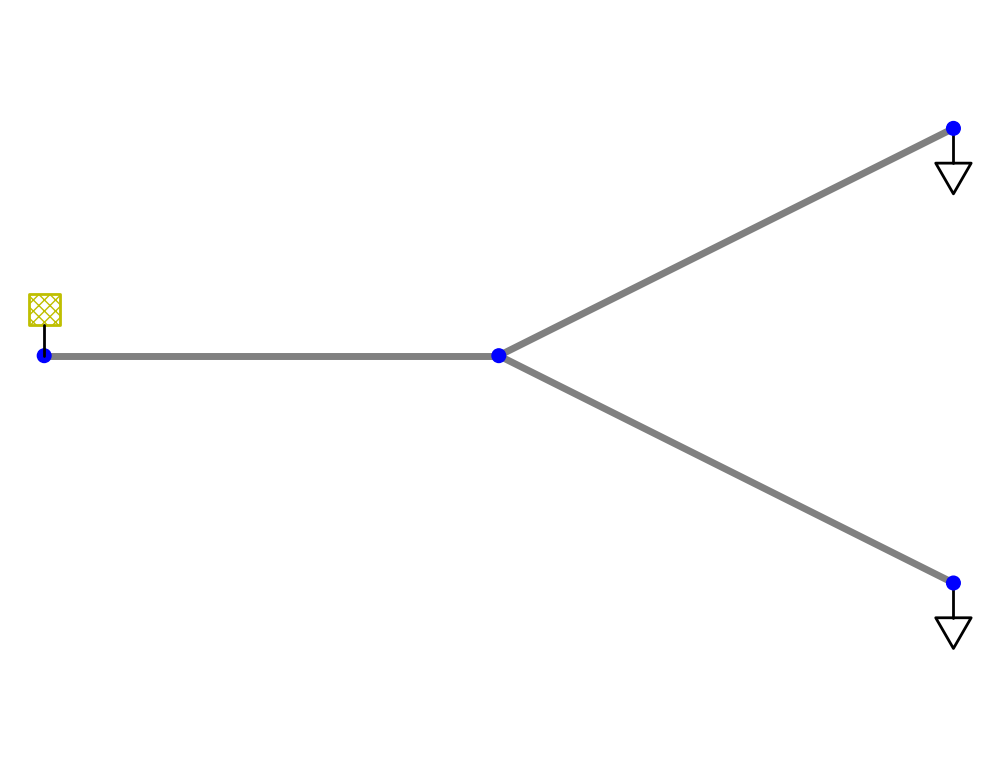

In [32]:
net_name = "2_four_bus_radial_2ph_grid_MP"
relevant_columns = ["name", "r_ohm_per_km", "x_ohm_per_km", "c_nf_per_km", "r0_ohm_per_km", "x0_ohm_per_km"]
net, dataframes = load_test_case_data(net_name, fault_location_bus)
plot(net)

This simple example illustrates how a 2-phase grid can be modeled as a 3-phase grid. Therefore, adaptations in the pandapower element tables e.g. lines and transformers are neccesarry. The equaitions are given below and will only affect the zero sequence parameters for this case. Positive and Negative sequence parameters are the same and remain unchanged.

\begin{align*}
\Huge Z_{\text{1-2ph}} &= \Huge Z_{\text{1-3ph}} \\
\\
\Huge Z_{\text{1-3ph}} &= \Huge Z_{\text{2-3ph}} \\
\\
\Huge Z_{\text{0-2ph}} &= \Huge1.5⋅\,Z_{\text{0-3ph}} - \Huge 0.5⋅\,Z_{\text{1-3ph}} \\
\end{align*}

More specifically resistance, reactance and capacitance need to be adapted. Furthermore the capacitance is neglected for the positive and negative sequence.

\begin{align*}
\Huge R_{\text{0-2ph}} &= \Huge 1.5⋅\,R_{\text{0-3ph}} - \Huge 0.5⋅\,R_{\text{1-3ph}} \\
\\
\Huge X_{\text{0-2ph}} &= \Huge 1.5⋅\,X_{\text{0-3ph}} - \Huge 0.5⋅\,X_{\text{1-3ph}} \\
\\
\Huge C_{\text{0-2ph}} &= \Huge 1.5⋅\,C_{\text{0-3ph}} - \Huge 0.5⋅\,C_{\text{1-3ph}} \\
\\
\Huge C_{\text{1-2ph}} &= \Huge C_{\text{2-2ph}} = 0
\end{align*}


In this small example grid we model three lines in total with one 3-phase line and two equivalent 2-phase lines with the same standard type.

In [33]:
net.line.std_type

0      NA2XRY 3x300sm 0.6/1kV_3ph
1    NA2XRY 3x300sm 0.6/1kV_3-2ph
2    NA2XRY 3x300sm 0.6/1kV_3-2ph
Name: std_type, dtype: object

Comparing the relevant parameters resistance, reactance and capacitance we can see the equivalent modeling of the 2-phase lines was correctly applied. The impacting parameters for positive/negative sequence for resistance and reactance remain unchanged. Capacitance is neglected. However, for the 3-phase line a capacitance could be respected, only in this example it is also set to zero.

In [34]:
net.line[relevant_columns]

,name,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,r0_ohm_per_km,x0_ohm_per_km
0,Line_0_3ph,0.1023,0.069115,0,0.40940,0.276460
1,Line_1_3-2ph,0.1023,0.069115,0,0.56295,0.380132
2,Line_2_3-2ph,0.1023,0.069115,0,0.56295,0.380132


The following parameters from the 3-phase line are used to calculate the equivalent parameters for the 2-phase lines.

In [35]:
line_3ph = net.line[net.line.name == "Line_0_3ph"]
line_3ph[relevant_columns]

,name,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,r0_ohm_per_km,x0_ohm_per_km
0,Line_0_3ph,0.1023,0.069115,0,0.4094,0.27646


In [36]:
line_2ph_equiv = pd.DataFrame({
    "r0_ohm_per_km_2ph_equiv": 1.5 * line_3ph["r0_ohm_per_km"] - 0.5 * line_3ph["r_ohm_per_km"],
    "x0_ohm_per_km_2ph_equiv": 1.5 * line_3ph["x0_ohm_per_km"] - 0.5 * line_3ph["x_ohm_per_km"]})
line_2ph_equiv

,r0_ohm_per_km_2ph_equiv,x0_ohm_per_km_2ph_equiv
0,0.56295,0.380133


Comparing the calculation above and the set parameters in the line table of the pandapower grid we can see that the parameters were calculated properly.

In [37]:
net.line[net.line.name== "Line_1_3-2ph"][["r0_ohm_per_km", "x0_ohm_per_km"]]

,r0_ohm_per_km,x0_ohm_per_km
1,0.56295,0.380132


We are now set to execute also multi-phase short circuit calculations. With the network and expected results loaded, we now can run the test to receive the dataframes and the columns that should be compared.

## Test Case 2: Four Bus Radial 2 phase grid

In [38]:
fault = "LG"
case = "max"
fault_values = (0.0, 0.0)
lv_tol_percents = 10
fault_location_bus = 3
is_branch_test = True
bus_or_branch = "branch" if is_branch_test else "bus"

columns_to_check, net_df, pf_results = run_test_cases(net, dataframes[bus_or_branch], fault, case, fault_values, lv_tol_percents, fault_location_bus, is_branch_test)
columns_to_check

Index(['ikss_a_from_ka', 'ikss_a_from_degree', 'ikss_a_to_ka',
       'ikss_a_to_degree', 'p_a_from_mw', 'q_a_from_mvar', 'p_a_to_mw',
       'q_a_to_mvar', 'vm_a_from_pu', 'va_a_from_degree', 'vm_a_to_pu',
       'va_a_to_degree', 'ikss_b_from_ka', 'ikss_b_from_degree',
       'ikss_b_to_ka', 'ikss_b_to_degree', 'p_b_from_mw', 'q_b_from_mvar',
       'p_b_to_mw', 'q_b_to_mvar', 'vm_b_from_pu', 'va_b_from_degree',
       'vm_b_to_pu', 'va_b_to_degree', 'ikss_c_from_ka', 'ikss_c_from_degree',
       'ikss_c_to_ka', 'ikss_c_to_degree', 'p_c_from_mw', 'q_c_from_mvar',
       'p_c_to_mw', 'q_c_to_mvar', 'vm_c_from_pu', 'va_c_from_degree',
       'vm_c_to_pu', 'va_c_to_degree'],
      dtype='object')

In [39]:
net_df[columns_to_check]

,ikss_a_from_ka,ikss_a_from_degree,ikss_a_to_ka,ikss_a_to_degree,p_a_from_mw,q_a_from_mvar,p_a_to_mw,q_a_to_mvar,vm_a_from_pu,va_a_from_degree,...,ikss_c_to_ka,ikss_c_to_degree,p_c_from_mw,q_c_from_mvar,p_c_to_mw,q_c_to_mvar,vm_c_from_pu,va_c_from_degree,vm_c_to_pu,va_c_to_degree
0,0.117436,-34.031228,0.117421,145.980115,2.472102e-02,0.016672,-0.010575,-0.00715,1.099428,-0.035864,...,0.000217,89.831258,-0.000054,-0.000031,0.000048,0.000043,1.100001,120.000079,1.288071,132.194926
1,0.000117,-90.216032,0.000000,0.000000,-5.784634e-08,0.000013,0.000000,0.00000,0.470751,0.043781,...,0.000000,0.000000,-0.000026,-0.000024,0.000000,0.000000,1.288071,132.194926,1.288925,132.189300
2,0.117355,-33.972281,0.117300,146.067997,1.057514e-02,0.007137,0.000000,0.00000,0.470751,0.043781,...,0.000000,0.000000,-0.000022,-0.000020,0.000000,0.000000,1.288071,132.194926,1.492663,140.258733


In [40]:
pf_results[columns_to_check]

,ikss_a_from_ka,ikss_a_from_degree,ikss_a_to_ka,ikss_a_to_degree,p_a_from_mw,q_a_from_mvar,p_a_to_mw,q_a_to_mvar,vm_a_from_pu,va_a_from_degree,...,ikss_c_to_ka,ikss_c_to_degree,p_c_from_mw,q_c_from_mvar,p_c_to_mw,q_c_to_mvar,vm_c_from_pu,va_c_from_degree,vm_c_to_pu,va_c_to_degree
0,0.117436,-34.031226,0.117421,145.980117,2.472103e-02,0.016672,-1.057508e-02,-7.150093e-03,1.099428,-0.035864,...,0.000217,89.826091,-0.000054,-0.000031,4.761264e-05,4.342884e-05,1.100001,120.000079,1.288071,132.194920
1,0.000117,-90.220926,0.000000,0.000000,-5.893700e-08,0.000013,1.085855e-09,4.346046e-12,0.470751,0.043786,...,0.000000,0.000000,-0.000026,-0.000024,-1.010073e-09,1.097657e-09,1.288071,132.194920,1.288925,132.189290
2,0.117355,-33.972274,0.117300,146.068004,1.057514e-02,0.007137,3.540384e-17,9.495085e-16,0.470751,0.043786,...,0.000000,0.000000,-0.000022,-0.000020,-2.521511e-09,2.084626e-09,1.288071,132.194920,1.492663,140.258728


# Test Case 3: Eight bus Radial 1 phase grid

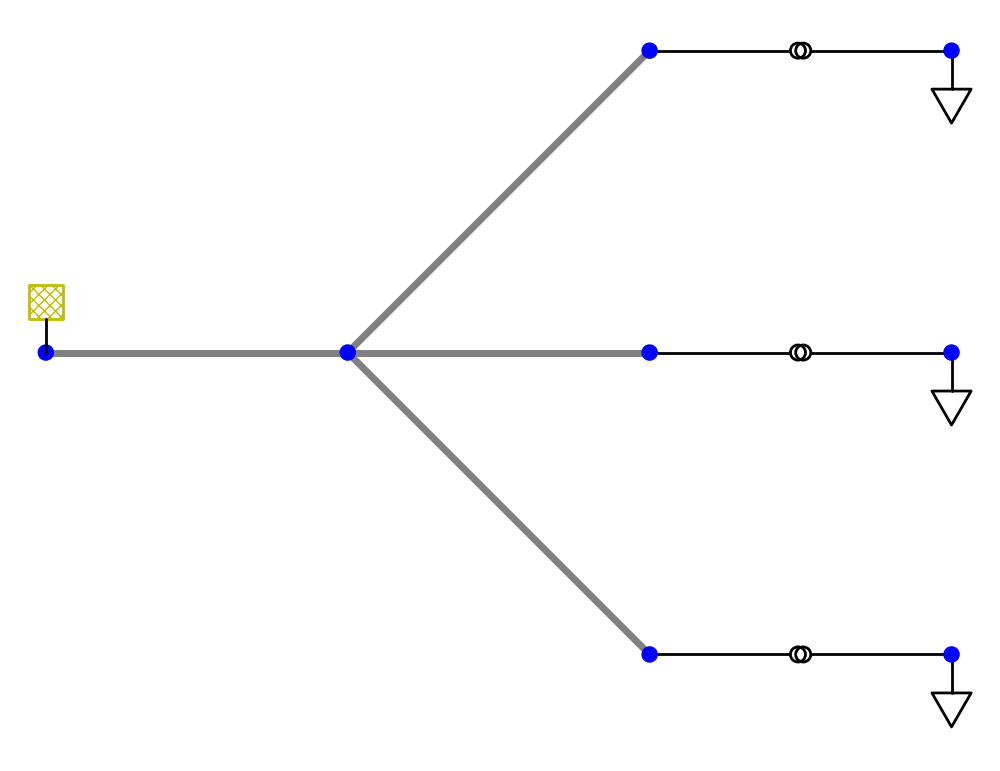

In [41]:
net_name = "7_eight_bus_radial_grid_1ph_ynyn_MP"

fault = "LG"
case = "max"
fault_values = (5.0, 5.0)
lv_tol_percents = 10
fault_location_bus = 6
is_branch_test = True
bus_or_branch = "branch" if is_branch_test else "bus"

net, dataframes = load_test_case_data(net_name, fault_location_bus)
plot(net)
columns_to_check, net_df, pf_results = run_test_cases(net, dataframes[bus_or_branch], fault, case, fault_values, lv_tol_percents, fault_location_bus, is_branch_test)

In [42]:
net_df[columns_to_check]

,ikss_a_from_ka,ikss_a_from_degree,ikss_a_to_ka,ikss_a_to_degree,p_a_from_mw,q_a_from_mvar,p_a_to_mw,q_a_to_mvar,vm_a_from_pu,va_a_from_degree,...,ikss_c_to_ka,ikss_c_to_degree,p_c_from_mw,q_c_from_mvar,p_c_to_mw,q_c_to_mvar,vm_c_from_pu,va_c_from_degree,vm_c_to_pu,va_c_to_degree
0,0.000718,-45.051346,0.000718,134.967417,0.006446,0.006456,-0.006443,-0.006448,1.099788,-0.009021,...,0.0,0.0,0.0,0.0,0.0,0.0,1.100000,120.000011,1.100059,120.001814
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.099680,-0.007421,...,0.0,0.0,0.0,0.0,0.0,0.0,1.100059,120.001814,1.100059,120.001814
2,0.000718,-45.032595,0.000718,134.967405,0.006443,0.006448,-0.006442,-0.006448,1.099680,-0.007421,...,0.0,0.0,0.0,0.0,0.0,0.0,1.100059,120.001814,1.100037,120.000797
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.099680,-0.007421,...,0.0,0.0,0.0,0.0,0.0,0.0,1.100059,120.001814,1.100059,120.001814


In [43]:
pf_results[columns_to_check]

,ikss_a_from_ka,ikss_a_from_degree,ikss_a_to_ka,ikss_a_to_degree,p_a_from_mw,q_a_from_mvar,p_a_to_mw,q_a_to_mvar,vm_a_from_pu,va_a_from_degree,...,ikss_c_to_ka,ikss_c_to_degree,p_c_from_mw,q_c_from_mvar,p_c_to_mw,q_c_to_mvar,vm_c_from_pu,va_c_from_degree,vm_c_to_pu,va_c_to_degree
0,0.000718,-45.051367,0.000718,134.967397,6.446226e-03,6.455761e-03,-6.442809e-03,-6.448475e-03,1.099788,-0.009021,...,0,0,-7.218331e-06,-1.163464e-06,-1.487535e-12,8.257571e-13,1.100000,120.000011,1.100059,120.001814
1,0.000000,0.000000,0.000000,0.000000,-2.582755e-12,1.148966e-12,2.582755e-12,-1.148966e-12,1.099680,-0.007421,...,0,0,4.762643e-13,-2.809269e-13,-4.762643e-13,2.809269e-13,1.100059,120.001814,1.100059,120.001814
2,0.000718,-45.032603,0.000718,134.967397,6.442809e-03,6.448475e-03,-6.442370e-03,-6.448258e-03,1.099680,-0.007421,...,0,0,2.968662e-13,-1.234330e-13,-2.968580e-13,1.234358e-13,1.100059,120.001814,1.100037,120.000797
3,0.000000,0.000000,0.000000,0.000000,-2.582755e-12,1.148969e-12,2.582755e-12,-1.148969e-12,1.099680,-0.007421,...,0,0,4.762694e-13,-2.809357e-13,-4.762694e-13,2.809357e-13,1.100059,120.001814,1.100059,120.001814


# Test Case 4: Eight bus Radial 2 phase grid

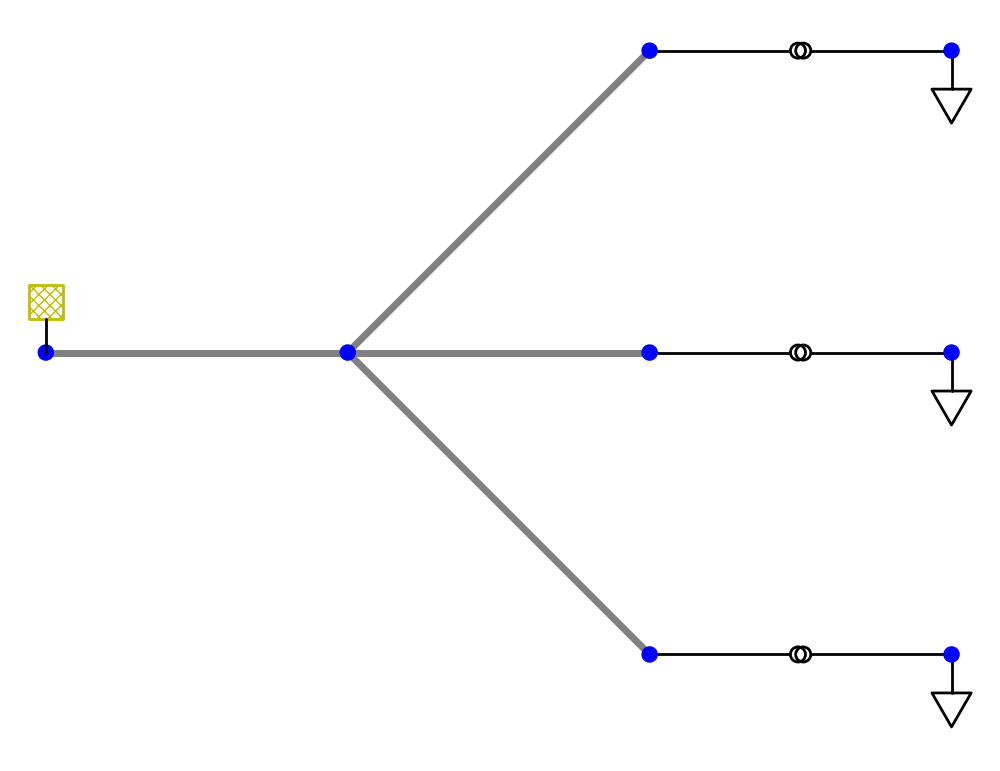

In [44]:
net_name = "9_eight_bus_radial_grid_2ph_yyn_MP"

fault = "LLG"
case = "min"
fault_values = (5.0, 5.0)
lv_tol_percents = 6
fault_location_bus = 2
is_branch_test = False
bus_or_branch = "branch" if is_branch_test else "bus"

net, dataframes = load_test_case_data(net_name, fault_location_bus)
plot(net)
columns_to_check, net_df, pf_results = run_test_cases(net, dataframes[bus_or_branch], fault, case, fault_values, lv_tol_percents, fault_location_bus, is_branch_test)

In [45]:
net_df[columns_to_check]

,ikss_a_ka,skss_a_mw,ikss_b_ka,skss_b_mw,ikss_c_ka,skss_c_mw,rk0_ohm,xk0_ohm,rk1_ohm,xk1_ohm,rk2_ohm,xk2_ohm
2,0.0,0.0,0.652803,7.537919,0.566711,6.543815,30.594477,15.099542,12.803119,11.710296,12.803119,11.710296


In [46]:
pf_results[columns_to_check]

,ikss_a_ka,skss_a_mw,ikss_b_ka,skss_b_mw,ikss_c_ka,skss_c_mw,rk0_ohm,xk0_ohm,rk1_ohm,xk1_ohm,rk2_ohm,xk2_ohm
2,0,0,0.652803,7.537921,0.566711,6.543811,30.594533,15.099496,12.803119,11.710296,12.803119,11.710296
